# EDA - Teclo Customer Churn Dataset

### Author - Mahith Perera

### Date - 28/08/2026

## Abstract

This Exploratory Data Analysis (EDA) systematically investigates the _*IBM Telco Customer Churn*_ dataset to uncover underlying patterns, distributions, and key factors associated with customer attrition. Initial data-quality procedures assessed dataset structure, schema integrity, missing values, duplicate records, and descriptive statistics. Data preprocessing included converting _SeniorCitizen_ from an integer representation to a categorical feature, converting _TotalCharges_ to a numerical format with appropriate missing-value treatment, removing the non-informative customerID identifier, and engineering binned tenure cohorts to support customer lifecycle analysis.

The analysis incorporated univariate distribution assessment using histograms and kernel density estimates for numerical variables. Bivariate count plots stratified by churn status were used to examine differences across demographic and service-related categorical variables. Comparative boxplot analysis was conducted to assess differences in numerical features between churned and retained customers, while a correlation matrix was used to identify relationships and potential multicollinearity among numerical variables.

Overall, the EDA provides a structured understanding of customer characteristics and patterns associated with churn, establishing an empirical foundation for subsequent feature engineering, predictive model development, model evaluation, and targeted customer retention strategies.

## Introduction

Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

Customers who left within the last month – the column is called Churn
Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
Demographic info about customers – gender, age range, and if they have partners and dependents
Inspiration
To explore this type of models and learn more about the subject.*_(1)_*


## Data Description

The **IBM Telco Customer Churn dataset** contains customer-level information from a telecommunications company and is designed to analyze and predict **customer churn**. Each record represents an individual customer and includes demographic information, account characteristics, subscribed services, billing details, and the customer's churn status.

The dataset contains **7,043 customer records and 21 original variables**. During preprocessing, the `customerID` variable was removed because it is a unique identifier and does not provide meaningful predictive information. The `SeniorCitizen` variable was converted from a numerical representation into a categorical feature, while `TotalCharges` was converted into a numerical format and its missing values were handled. In addition, a new `tenure_group` feature was engineered to categorize customers according to their length of service.

### Main Variables

| Variable | Data Type | Description |
|---|---|---|
| `customerID` | Identifier | Unique identifier for each customer; removed during analysis |
| `gender` | Categorical | Customer's gender |
| `SeniorCitizen` | Categorical | Indicates whether the customer is a senior citizen |
| `Partner` | Categorical | Indicates whether the customer has a partner |
| `Dependents` | Categorical | Indicates whether the customer has dependents |
| `tenure` | Numerical | Number of months the customer has stayed with the company |
| `PhoneService` | Categorical | Indicates whether the customer has phone service |
| `MultipleLines` | Categorical | Indicates whether the customer has multiple phone lines |
| `InternetService` | Categorical | Type of internet service subscribed to |
| `OnlineSecurity` | Categorical | Indicates whether online security is subscribed |
| `OnlineBackup` | Categorical | Indicates whether online backup is subscribed |
| `DeviceProtection` | Categorical | Indicates whether device protection is subscribed |
| `TechSupport` | Categorical | Indicates whether technical support is subscribed |
| `StreamingTV` | Categorical | Indicates whether the customer has streaming TV |
| `StreamingMovies` | Categorical | Indicates whether the customer has streaming movie services |
| `Contract` | Categorical | Type of customer contract |
| `PaperlessBilling` | Categorical | Indicates whether paperless billing is enabled |
| `PaymentMethod` | Categorical | Customer's payment method |
| `MonthlyCharges` | Numerical | Customer's monthly billing amount |
| `TotalCharges` | Numerical | Total amount charged to the customer |
| `Churn` | Categorical | Indicates whether the customer left the company |
| `tenure_group` | Categorical | Engineered tenure categories: 0–12, 13–24, 25–36, 37–48, and 49+ months |

### Target Variable

The primary target variable is **`Churn`**, which indicates whether a customer discontinued the company's services.

- **Yes** → Customer churned
- **No** → Customer remained with the company

The dataset is therefore suitable for a **binary classification problem**, where the objective is to predict whether a customer is likely to churn based on their demographic, service, contract, and billing characteristics.

### Data Characteristics

The dataset consists of:

- **Numerical variables:** `tenure`, `MonthlyCharges`, and `TotalCharges`
- **Categorical variables:** demographic, service, contract, and payment-related features
- **Target variable:** `Churn`
- **Engineered feature:** `tenure_group`

These variables allow the EDA to examine customer distributions and identify relationships and patterns associated with **customer churn**, providing a foundation for subsequent machine-learning modeling.

### Data Quality

The dataset contains 7,043 customer records and 21 variables. An initial data-quality assessment was performed to identify missing values, duplicate observations, and the statistical characteristics of the numerical variables.

Missing Values

The missing-value analysis shows that none of the 21 columns contain missing values. Every variable has 7,043 non-null observations. Therefore, no missing-value imputation was required at this stage.

Duplicate Records

The dataset contains 0 duplicate rows, indicating that each customer record is unique based on the complete set of variables.

Numerical Summary

Descriptive statistics were examined for the numerical variables SeniorCitizen, tenure, and MonthlyCharges.

| Variable | Mean | Median | Std. Dev. | Min | Max |
|---|---:|---:|---:|---:|---:|
| SeniorCitizen | 0.162 | 0 | 0.369 | 0 | 1 |
| tenure | 32.37 | 29 | 24.56 | 0 | 72 |
| MonthlyCharges | 64.76 | 70.35 | 30.09 | 18.25 | 118.75 |

Key observations:

- _SeniorCitizen_ is a binary variable containing values 0 and 1. Its mean of 0.162 indicates that approximately **_16.2%_** of customers are senior citizens.

- _Tenure_ ranges from 0 to 72 months, with an average of approximately 32.4 months. The median tenure is 29 months, indicating that half of the customers have been with the company for **_29 months_** or less.

- _MonthlyCharges_ ranges from 18.25 to 118.75, with an average monthly charge of approximately **_64.76_**. The median is 70.35, which is higher than the mean, suggesting that the distribution may warrant further investigation during the univariate analysis.

- The absence of missing values and duplicate records indicates that the dataset has good structural data quality for subsequent exploratory analysis.


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(df.head(10))

print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNumerical summary:")
print(df.describe())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

## Data Preprocessing and Feature Engineering

Several preprocessing steps were performed to improve data consistency and prepare the dataset for exploratory analysis and subsequent machine learning.

### Data Type Conversion

The `SeniorCitizen` variable was originally stored as an integer with values `0` and `1`. Since it represents a categorical characteristic rather than a continuous numerical measurement, it was converted into categorical labels:

- `0` → `No`
- `1` → `Yes`

The `TotalCharges` variable was converted to a numerical data type using `pd.to_numeric()`. 

### Feature Engineering

A new categorical feature, `tenure_group`, was created from the `tenure` variable to facilitate analysis of customer behavior across different tenure ranges.

The groups were defined as follows:

| Tenure Group | Range |
|---|---:|
| 0-12 | 0–12 months |
| 13-24 | 13–24 months |
| 25-36 | 25–36 months |
| 37-48 | 37–48 months |
| 49+ | 49 months and above |

This transformation enables a clearer comparison of customer churn patterns across different stages of the customer lifecycle.

### Removal of Identifier

The `customerID` column was removed because it is a unique identifier and does not provide meaningful predictive information for customer churn analysis. Retaining such an identifier could unnecessarily increase the dimensionality of the dataset without contributing useful analytical information.

### Feature Type Identification

The remaining variables were separated into numerical and categorical feature groups based on their data types. This classification supports the selection of appropriate visualization, statistical analysis, encoding, and preprocessing techniques in subsequent stages of the EDA and machine learning workflow.`

In [3]:
# Converting because it is identified as an int
df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Yes", 0: "No"})

# Convert TotalCharges to numeric (handles blank strings " " -> NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


# Feature Engineering: Create tenure groups
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 36, 48, float("inf")],
    labels=["0-12", "13-24", "25-36", "37-48", "49+"],
)

# FIX: Drop customerID without specifying axis=1 when using the columns keyword
df = df.drop(columns=["customerID"],errors='ignore')

# Select numerical and categorical columns
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

print("\nNumerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))


Numerical Columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'tenure_group']


## Univariate Analysis

### Numerical Analysis

The univariate analysis provided an overall understanding of the distribution and characteristics of the variables in the Telco Customer Churn dataset.

The numerical variables showed different distributional patterns, with variations in central tendency, spread, and skewness. `tenure`, `MonthlyCharges`, and `TotalCharges` demonstrated considerable variation across customers, highlighting differences in customer service duration and spending behavior. These distributions will require further examination with their relationship with customer churn.

The categorical analysis showed that customer characteristics, service usage, contract types, and payment methods are not equally distributed across all categories. Some categories represent substantially larger proportions of the customer base than others. The `Churn` variable also showed an unequal distribution between customers who churned and those who remained, indicating potential class imbalance in the target variable.

Overall, the univariate analysis establishes the fundamental characteristics of the dataset and identifies important distributional patterns that should be considered in subsequent bivariate and multivariate analysis. The next stage will investigate relationships between individual features and customer churn to identify variables that may be important predictors of customer attrition.

#### Categorical Univariate Analysis

The categorical univariate analysis provided an overview of the composition of the customer base across demographic characteristics, service-related attributes, contract types, billing preferences, and payment methods.

The analysis revealed that the categorical variables have different levels of representation across their respective categories. Some categories account for a substantially larger proportion of customers than others, indicating that the customer base is not uniformly distributed across all demographic and service characteristics.

Variables such as `Contract`, `InternetService`, `PaymentMethod`, and other service-related features show distinct differences in category frequencies. These variations provide useful information about the overall structure of the customer population and may be important when investigating customer churn.

The analysis also confirmed that several categorical variables contain multiple distinct categories, while others are binary variables with two possible outcomes. Understanding these distributions is important for selecting appropriate encoding and preprocessing techniques before machine learning.

Overall, the categorical univariate analysis established the composition and distribution of the customer base but does not determine relationships between variables. Therefore, the next stage of the EDA will focus on **bivariate analysis**, particularly examining the relationship between individual categorical variables and the target variable `Churn`.

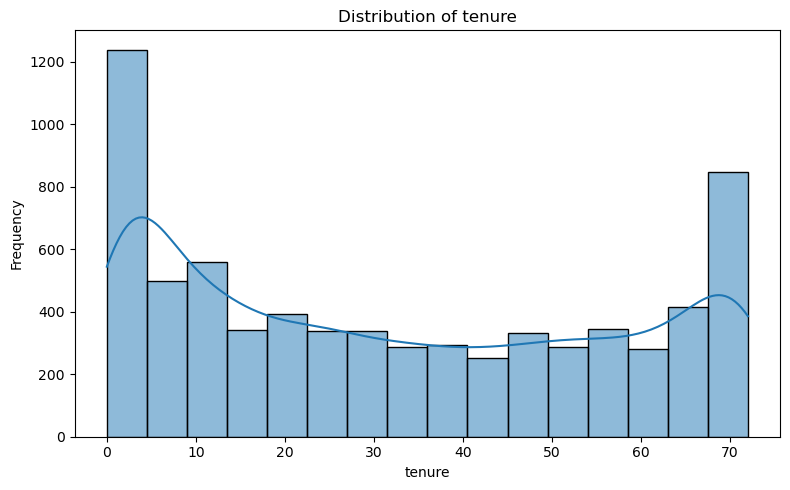


### Distribution of `tenure`

**Conclusion:**

- The distribution is **approximately symmetric**.
- The mean is **32.37** and the median is **29.00**.
- The values range from **0.00** to **72.00**.
- The standard deviation is **24.56**.


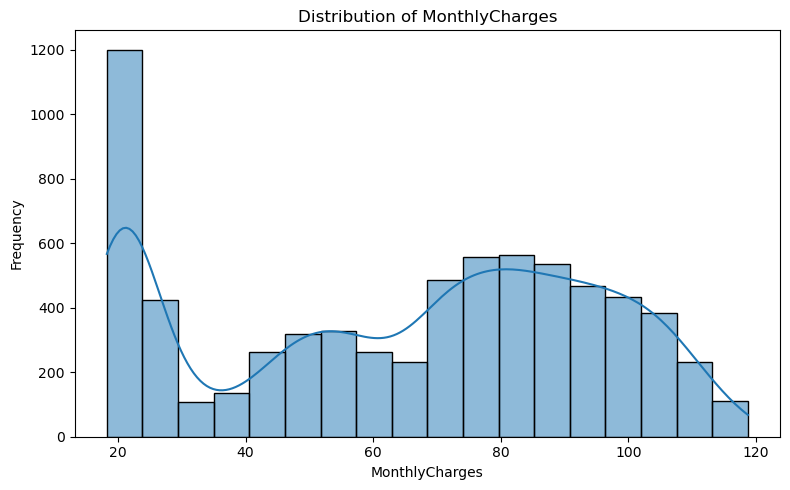


### Distribution of `MonthlyCharges`

**Conclusion:**

- The distribution is **approximately symmetric**.
- The mean is **64.76** and the median is **70.35**.
- The values range from **18.25** to **118.75**.
- The standard deviation is **30.09**.


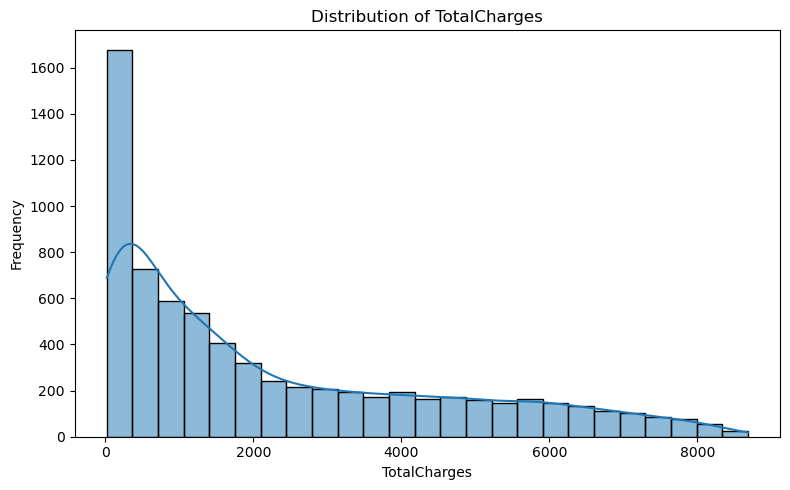


### Distribution of `TotalCharges`

**Conclusion:**

- The distribution is **positively skewed (right-skewed)**.
- The mean is **2283.30** and the median is **1397.47**.
- The values range from **18.80** to **8684.80**.
- The standard deviation is **2266.77**.


In [13]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Create folder for charts
os.makedirs("eda_charts", exist_ok=True)

for i in num_cols:

    # Create chart
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=i, kde=True)
    plt.title(f"Distribution of {i}")
    plt.xlabel(i)
    plt.ylabel("Frequency")
    plt.tight_layout()

    # Save chart
    file_path = f"eda_charts/{i}_distribution.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # Statistics
    mean = df[i].mean()
    median = df[i].median()
    skew = df[i].skew()

    # Determine skewness
    if abs(skew) < 0.5:
        shape = "approximately symmetric"
    elif skew > 0:
        shape = "positively skewed (right-skewed)"
    else:
        shape = "negatively skewed (left-skewed)"

    # Display as actual Markdown
    display(Markdown(f"""
### Distribution of `{i}`

**Conclusion:**

- The distribution is **{shape}**.
- The mean is **{mean:.2f}** and the median is **{median:.2f}**.
- The values range from **{df[i].min():.2f}** to **{df[i].max():.2f}**.
- The standard deviation is **{df[i].std():.2f}**.
"""))

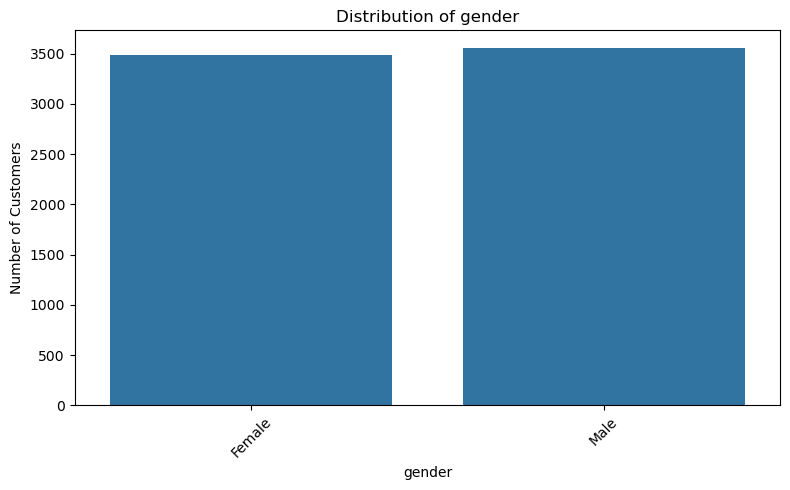


### Distribution of `gender`

**Conclusion:**

- The most common category is **Male**, representing **50.48%** of customers.
- The least common category is **Female**, representing **49.52%** of customers.
- The variable contains **2** distinct categories.


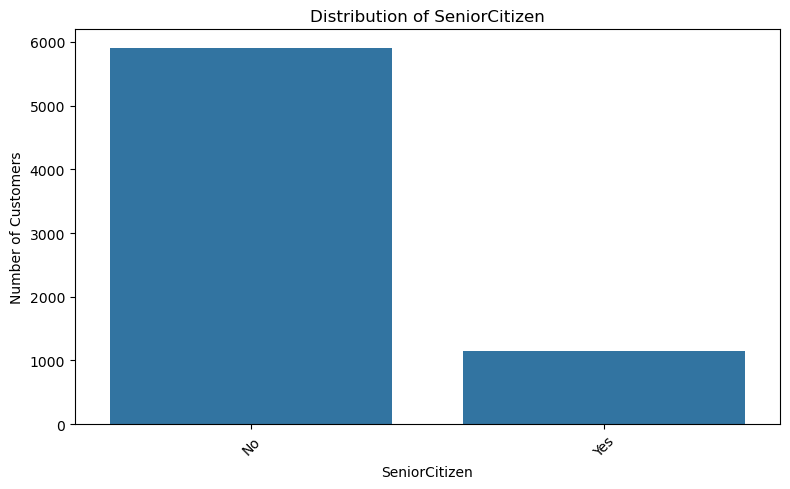


### Distribution of `SeniorCitizen`

**Conclusion:**

- The most common category is **No**, representing **83.79%** of customers.
- The least common category is **Yes**, representing **16.21%** of customers.
- The variable contains **2** distinct categories.


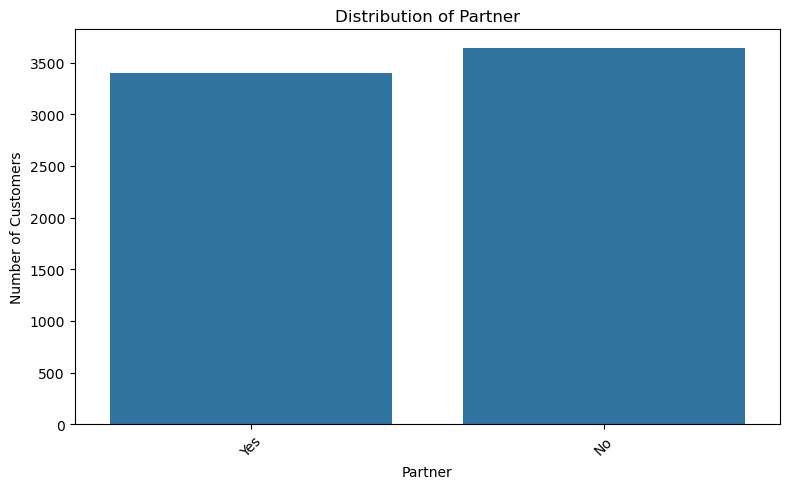


### Distribution of `Partner`

**Conclusion:**

- The most common category is **No**, representing **51.70%** of customers.
- The least common category is **Yes**, representing **48.30%** of customers.
- The variable contains **2** distinct categories.


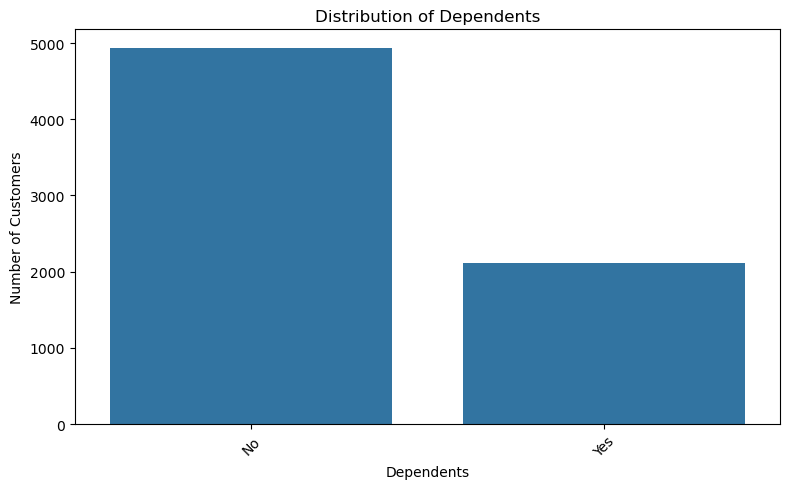


### Distribution of `Dependents`

**Conclusion:**

- The most common category is **No**, representing **70.04%** of customers.
- The least common category is **Yes**, representing **29.96%** of customers.
- The variable contains **2** distinct categories.


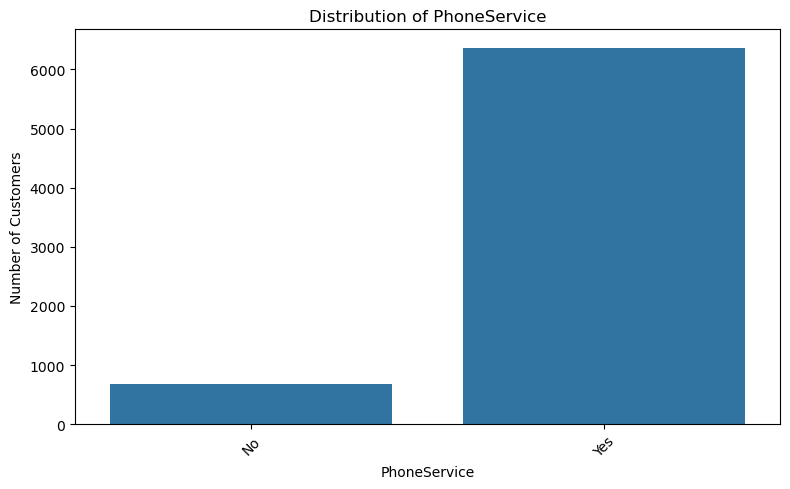


### Distribution of `PhoneService`

**Conclusion:**

- The most common category is **Yes**, representing **90.32%** of customers.
- The least common category is **No**, representing **9.68%** of customers.
- The variable contains **2** distinct categories.


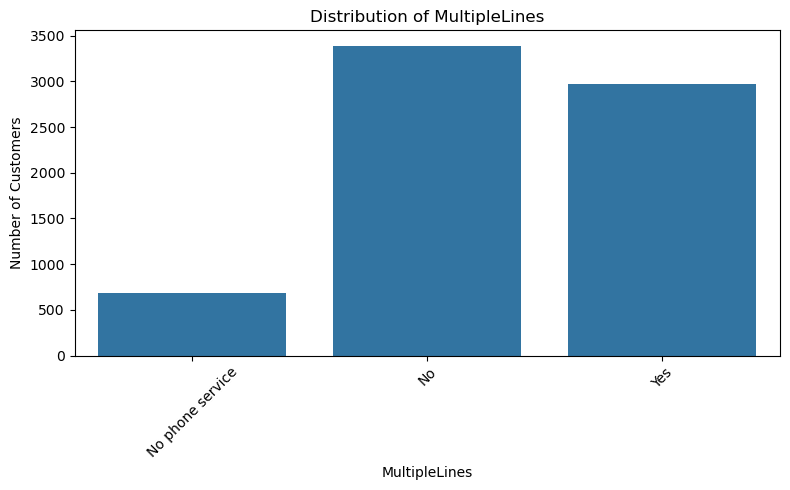


### Distribution of `MultipleLines`

**Conclusion:**

- The most common category is **No**, representing **48.13%** of customers.
- The least common category is **No phone service**, representing **9.68%** of customers.
- The variable contains **3** distinct categories.


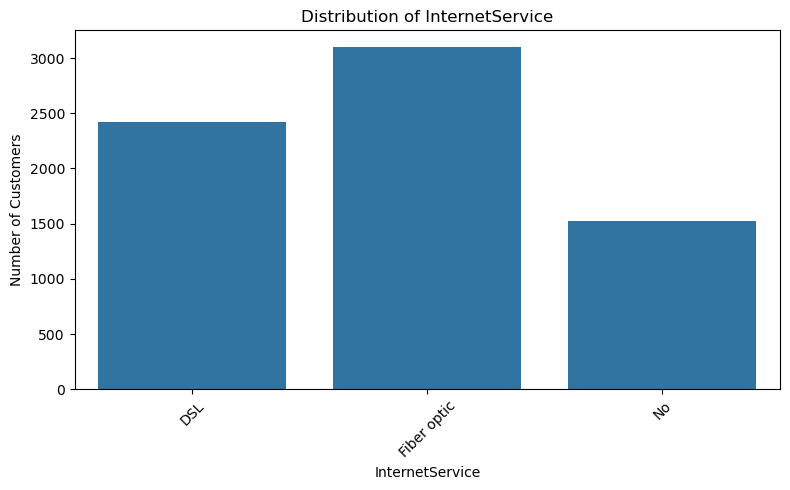


### Distribution of `InternetService`

**Conclusion:**

- The most common category is **Fiber optic**, representing **43.96%** of customers.
- The least common category is **No**, representing **21.67%** of customers.
- The variable contains **3** distinct categories.


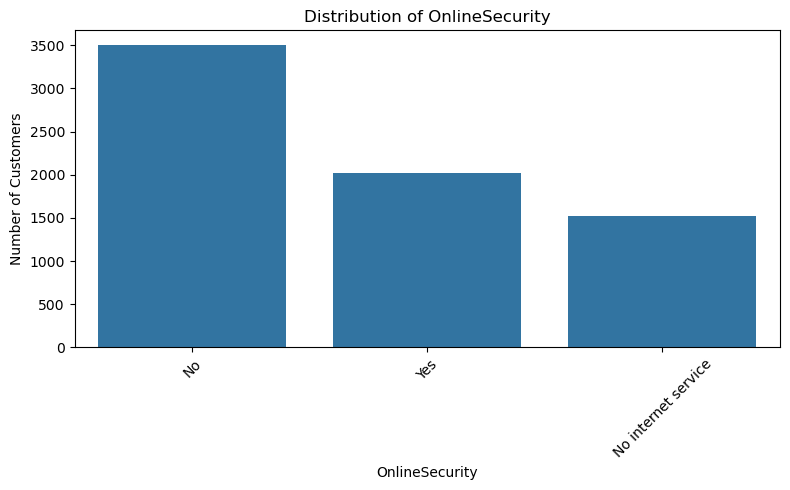


### Distribution of `OnlineSecurity`

**Conclusion:**

- The most common category is **No**, representing **49.67%** of customers.
- The least common category is **No internet service**, representing **21.67%** of customers.
- The variable contains **3** distinct categories.


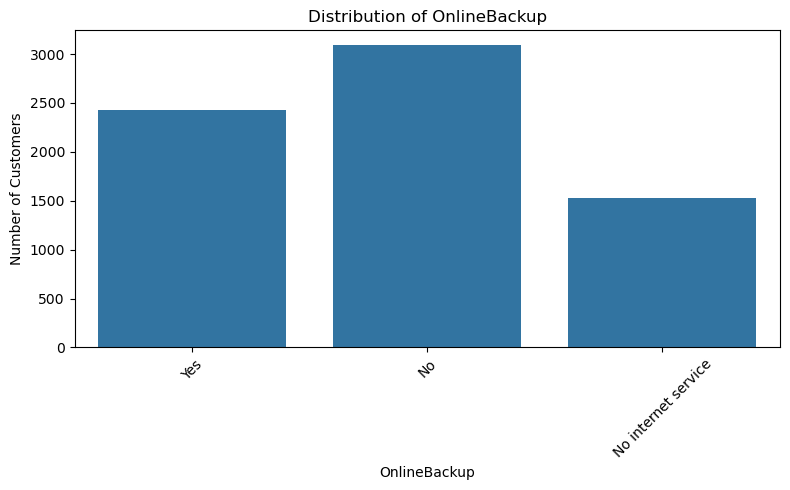


### Distribution of `OnlineBackup`

**Conclusion:**

- The most common category is **No**, representing **43.84%** of customers.
- The least common category is **No internet service**, representing **21.67%** of customers.
- The variable contains **3** distinct categories.


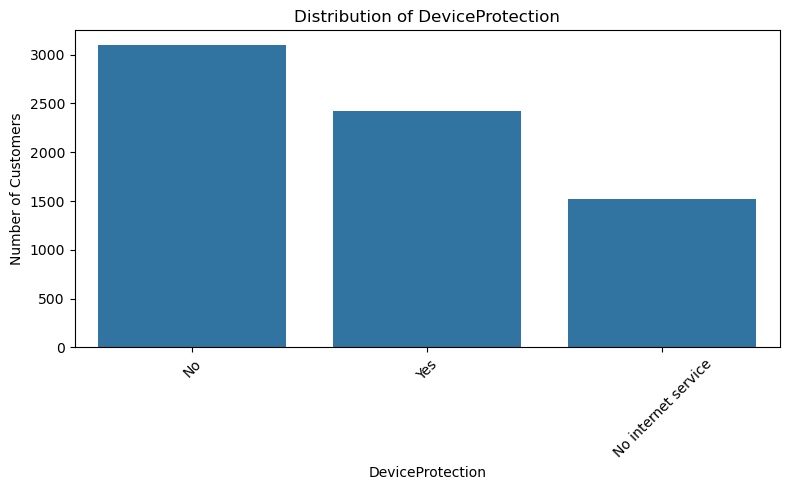


### Distribution of `DeviceProtection`

**Conclusion:**

- The most common category is **No**, representing **43.94%** of customers.
- The least common category is **No internet service**, representing **21.67%** of customers.
- The variable contains **3** distinct categories.


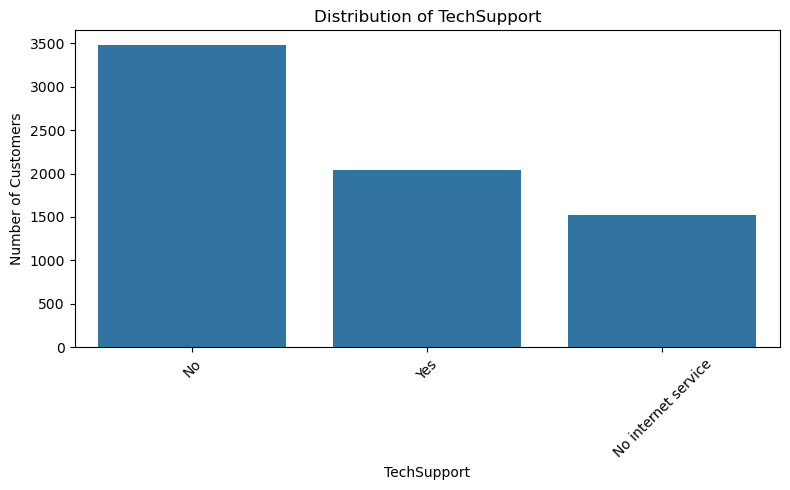


### Distribution of `TechSupport`

**Conclusion:**

- The most common category is **No**, representing **49.31%** of customers.
- The least common category is **No internet service**, representing **21.67%** of customers.
- The variable contains **3** distinct categories.


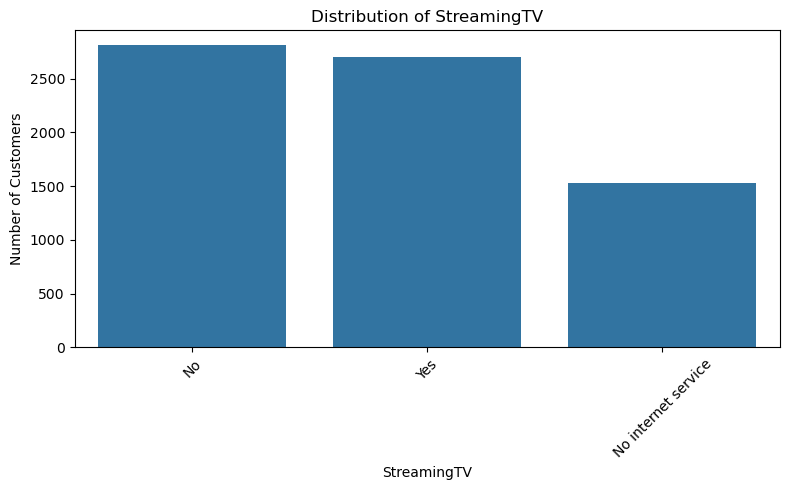


### Distribution of `StreamingTV`

**Conclusion:**

- The most common category is **No**, representing **39.90%** of customers.
- The least common category is **No internet service**, representing **21.67%** of customers.
- The variable contains **3** distinct categories.


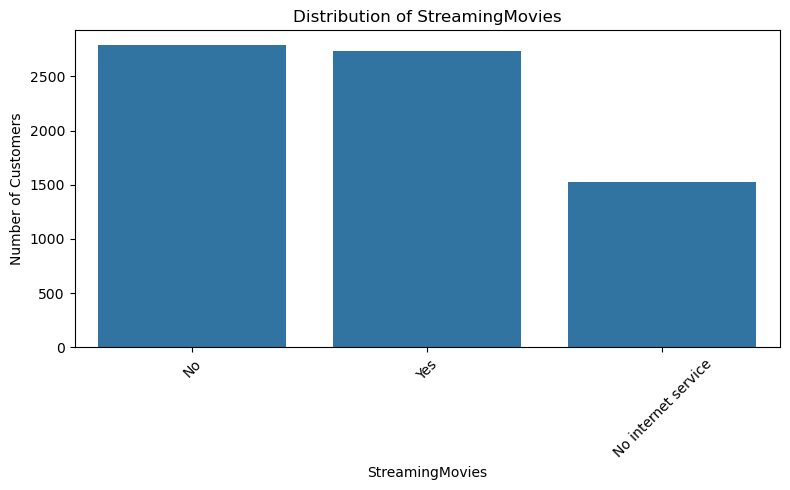


### Distribution of `StreamingMovies`

**Conclusion:**

- The most common category is **No**, representing **39.54%** of customers.
- The least common category is **No internet service**, representing **21.67%** of customers.
- The variable contains **3** distinct categories.


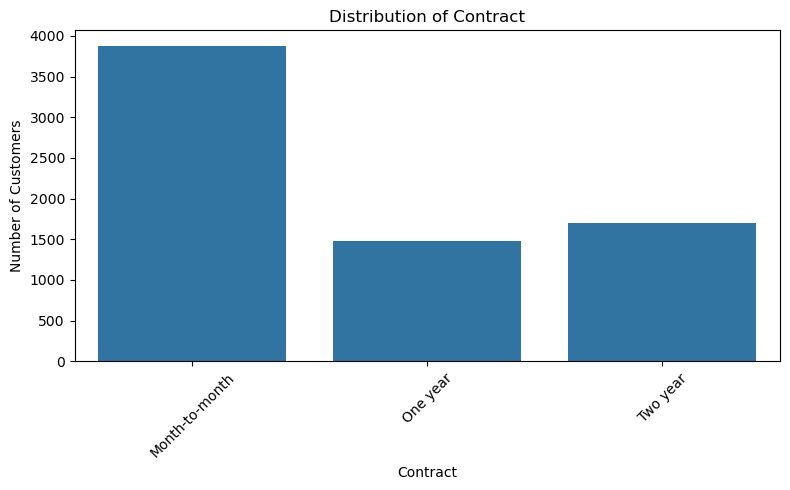


### Distribution of `Contract`

**Conclusion:**

- The most common category is **Month-to-month**, representing **55.02%** of customers.
- The least common category is **One year**, representing **20.91%** of customers.
- The variable contains **3** distinct categories.


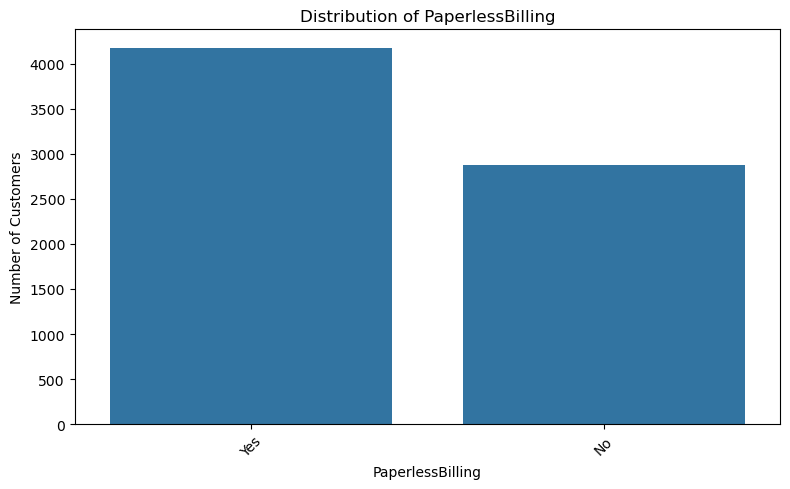


### Distribution of `PaperlessBilling`

**Conclusion:**

- The most common category is **Yes**, representing **59.22%** of customers.
- The least common category is **No**, representing **40.78%** of customers.
- The variable contains **2** distinct categories.


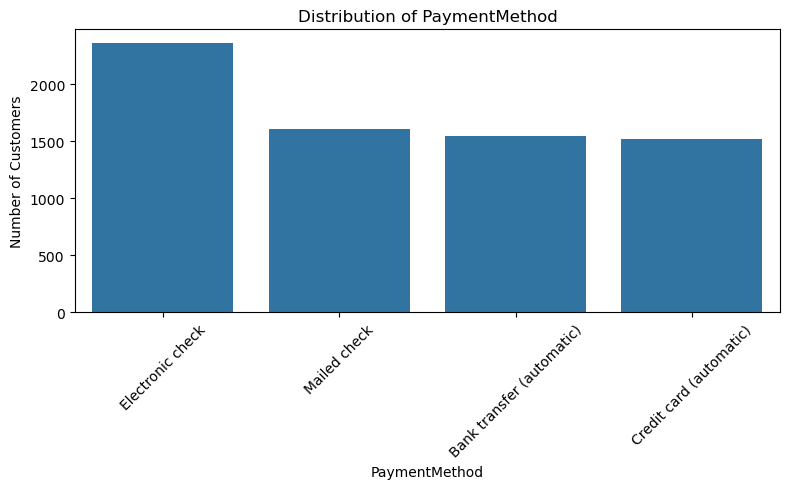


### Distribution of `PaymentMethod`

**Conclusion:**

- The most common category is **Electronic check**, representing **33.58%** of customers.
- The least common category is **Credit card (automatic)**, representing **21.61%** of customers.
- The variable contains **4** distinct categories.


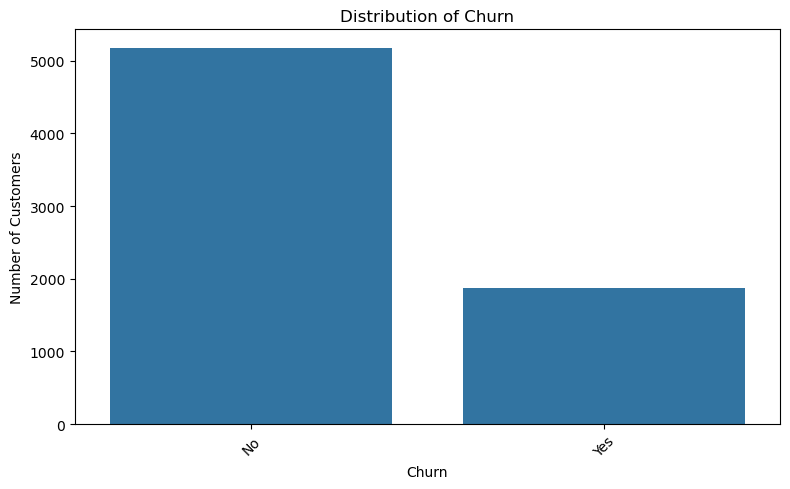


### Distribution of `Churn`

**Conclusion:**

- The most common category is **No**, representing **73.46%** of customers.
- The least common category is **Yes**, representing **26.54%** of customers.
- The variable contains **2** distinct categories.


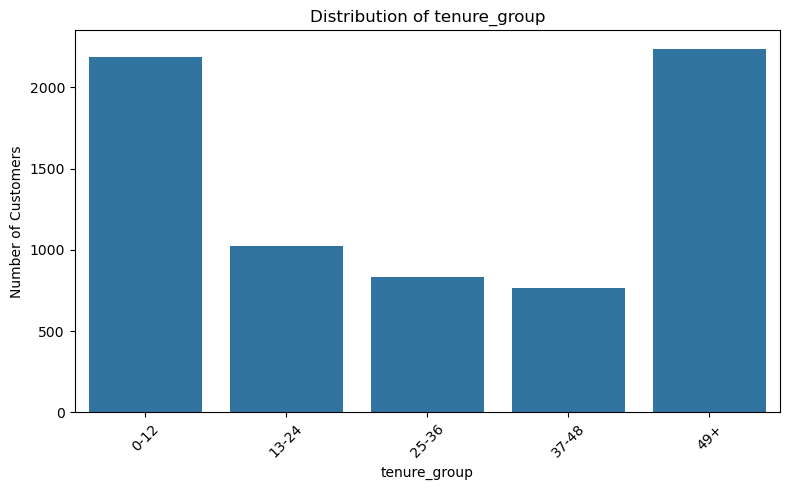


### Distribution of `tenure_group`

**Conclusion:**

- The most common category is **49+**, representing **31.79%** of customers.
- The least common category is **37-48**, representing **10.82%** of customers.
- The variable contains **5** distinct categories.


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

for i in cat_cols:

    # Create count plot
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=i)
    plt.title(f"Distribution of {i}")
    plt.xlabel(i)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Calculate counts and percentages
    counts = df[i].value_counts()
    percentages = df[i].value_counts(normalize=True).mul(100)

    # Largest and smallest categories
    largest_category = counts.idxmax()
    largest_percentage = percentages[largest_category]

    smallest_category = counts.idxmin()
    smallest_percentage = percentages[smallest_category]

    # Display Markdown conclusion
    display(Markdown(f"""
### Distribution of `{i}`

**Conclusion:**

- The most common category is **{largest_category}**, representing **{largest_percentage:.2f}%** of customers.
- The least common category is **{smallest_category}**, representing **{smallest_percentage:.2f}%** of customers.
- The variable contains **{df[i].nunique()}** distinct categories.
"""))

## Bivariate Analysis

The bivariate analysis examined the relationships between the predictor variables and the target variable, `Churn`, using both numerical and categorical features.

### Numerical Variables vs Churn

The analysis of numerical variables using box plots showed differences in the distributions of `tenure`, `MonthlyCharges`, and `TotalCharges` between customers who churned and those who remained. In particular, differences in median values and distributional spread indicate that customer tenure and charging patterns may be associated with churn behavior. Customers with different levels of tenure and monthly or total charges exhibit different churn patterns, suggesting that these variables may provide useful information for predicting customer attrition.

### Categorical Variables vs Churn

The analysis of categorical variables using count plots and category-level churn rates revealed substantial differences in churn behavior across several customer characteristics, service types, contract arrangements, and payment methods. Some categories demonstrated considerably higher churn rates than others, indicating potential associations between these categorical features and customer churn.

Variables such as `Contract`, `InternetService`, `PaymentMethod`, and other service-related characteristics show differences in churn rates across their categories. These differences suggest that customer characteristics and service arrangements may play an important role in explaining customer attrition.

### Overall Finding

Overall, the bivariate analysis identified several numerical and categorical variables that appear to be associated with `Churn`. However, these relationships should not be interpreted as causal relationships. Further multivariate analysis and statistical testing are required to determine whether these variables remain important when the effects of other features are considered.

The findings from this analysis provide a foundation for **feature selection, feature engineering, and machine learning model development**. The next stage will investigate interactions among multiple variables and assess whether the identified patterns remain consistent when several predictors are considered simultaneously.

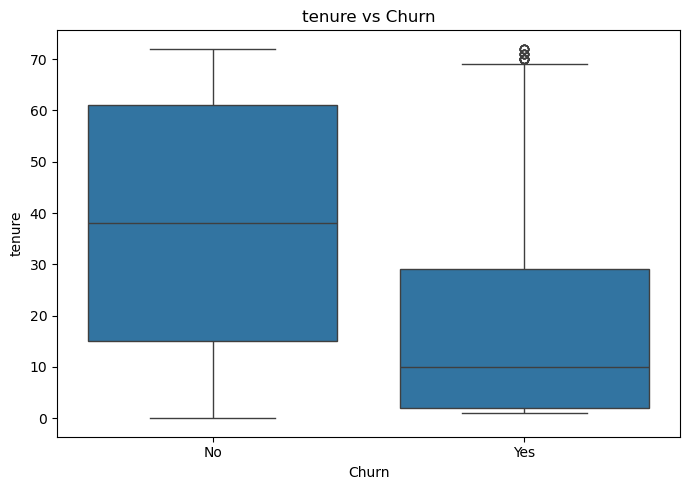


### tenure vs Churn

**Conclusion:**

- The median `tenure` for customers who **churned** is **10.00**.
- The median `tenure` for customers who **did not churn** is **38.00**.
- The mean `tenure` for customers who **churned** is **17.98**.
- The mean `tenure` for customers who **did not churn** is **37.57**.
- **Interpretation:** Customers who churned have a lower median tenure (10.00) than customers who did not churn (38.00).

The box plots also provide information about the spread and potential outliers within each churn group.


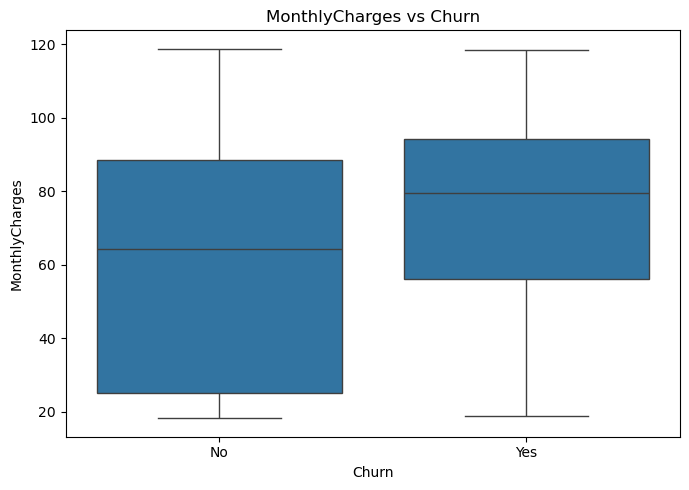


### MonthlyCharges vs Churn

**Conclusion:**

- The median `MonthlyCharges` for customers who **churned** is **79.65**.
- The median `MonthlyCharges` for customers who **did not churn** is **64.43**.
- The mean `MonthlyCharges` for customers who **churned** is **74.44**.
- The mean `MonthlyCharges` for customers who **did not churn** is **61.27**.
- **Interpretation:** Customers who churned have a higher median MonthlyCharges (79.65) than customers who did not churn (64.43).

The box plots also provide information about the spread and potential outliers within each churn group.


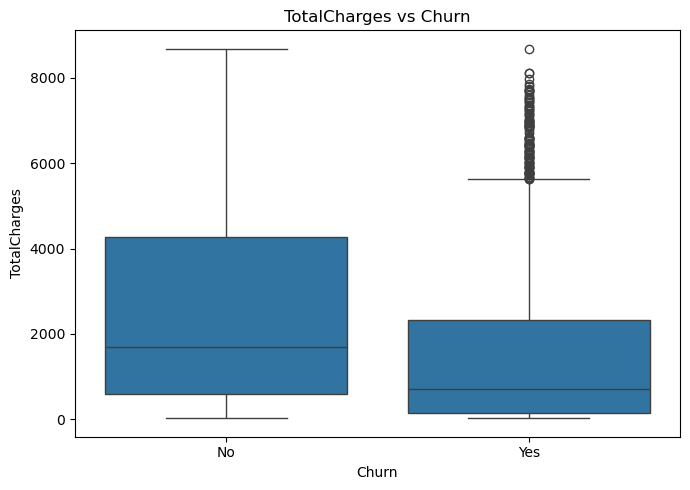


### TotalCharges vs Churn

**Conclusion:**

- The median `TotalCharges` for customers who **churned** is **703.55**.
- The median `TotalCharges` for customers who **did not churn** is **1683.60**.
- The mean `TotalCharges` for customers who **churned** is **1531.80**.
- The mean `TotalCharges` for customers who **did not churn** is **2555.34**.
- **Interpretation:** Customers who churned have a lower median TotalCharges (703.55) than customers who did not churn (1683.60).

The box plots also provide information about the spread and potential outliers within each churn group.


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

for col in num_cols:

    # Create box plot
    plt.figure(figsize=(7, 5))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Calculate group statistics
    churn_median = df.loc[df["Churn"] == "Yes", col].median()
    no_churn_median = df.loc[df["Churn"] == "No", col].median()

    churn_mean = df.loc[df["Churn"] == "Yes", col].mean()
    no_churn_mean = df.loc[df["Churn"] == "No", col].mean()

    # Determine which group has the higher median
    if churn_median > no_churn_median:
        median_comparison = (
            f"Customers who churned have a higher median {col} "
            f"({churn_median:.2f}) than customers who did not churn "
            f"({no_churn_median:.2f})."
        )
    elif churn_median < no_churn_median:
        median_comparison = (
            f"Customers who churned have a lower median {col} "
            f"({churn_median:.2f}) than customers who did not churn "
            f"({no_churn_median:.2f})."
        )
    else:
        median_comparison = (
            f"The median {col} is the same for both churn groups "
            f"({churn_median:.2f})."
        )

    # Display Markdown conclusion
    display(Markdown(f"""
### {col} vs Churn

**Conclusion:**

- The median `{col}` for customers who **churned** is **{churn_median:.2f}**.
- The median `{col}` for customers who **did not churn** is **{no_churn_median:.2f}**.
- The mean `{col}` for customers who **churned** is **{churn_mean:.2f}**.
- The mean `{col}` for customers who **did not churn** is **{no_churn_mean:.2f}**.
- **Interpretation:** {median_comparison}

The box plots also provide information about the spread and potential outliers within each churn group.
"""))

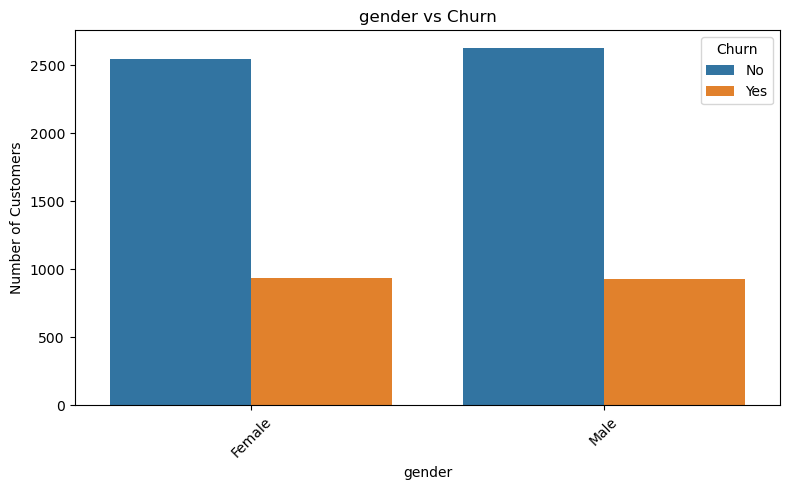


### gender vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **Female**, with a churn rate of **26.92%**.
- The category with the **lowest churn rate** is **Male**, with a churn rate of **26.16%**.
- The difference in churn rates across categories suggests that `gender` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


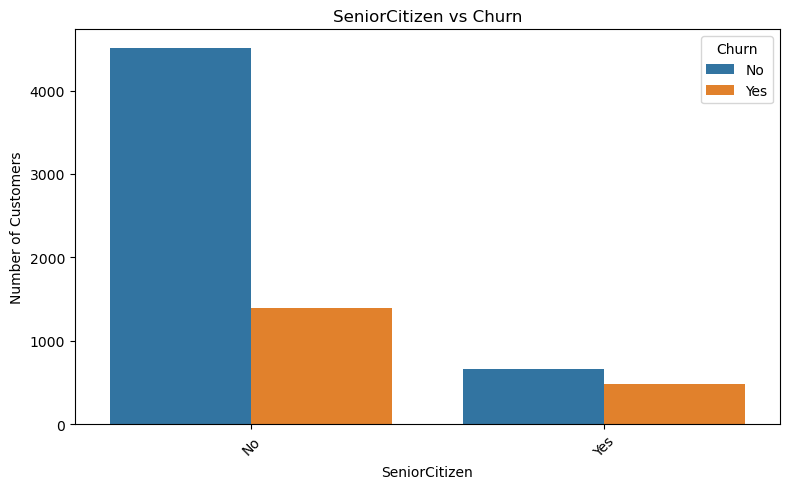


### SeniorCitizen vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **Yes**, with a churn rate of **41.68%**.
- The category with the **lowest churn rate** is **No**, with a churn rate of **23.61%**.
- The difference in churn rates across categories suggests that `SeniorCitizen` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


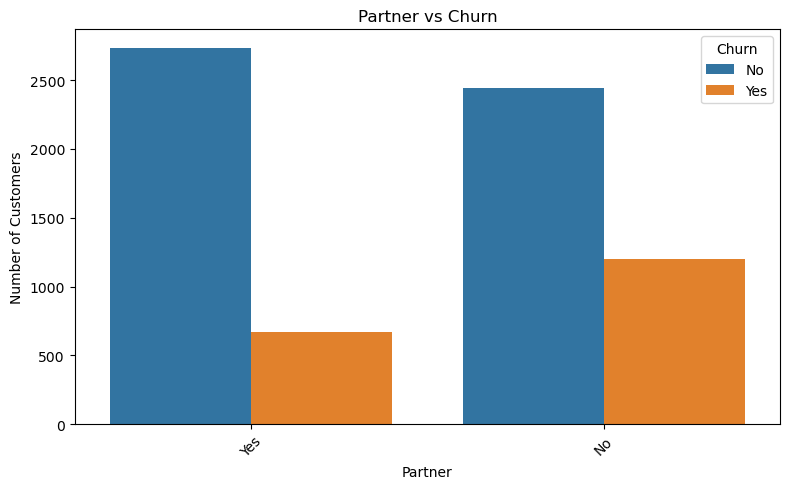


### Partner vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **No**, with a churn rate of **32.96%**.
- The category with the **lowest churn rate** is **Yes**, with a churn rate of **19.66%**.
- The difference in churn rates across categories suggests that `Partner` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


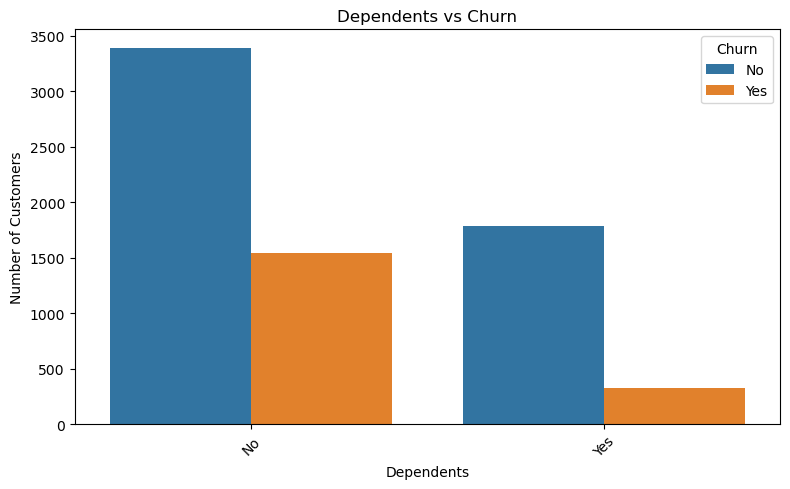


### Dependents vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **No**, with a churn rate of **31.28%**.
- The category with the **lowest churn rate** is **Yes**, with a churn rate of **15.45%**.
- The difference in churn rates across categories suggests that `Dependents` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


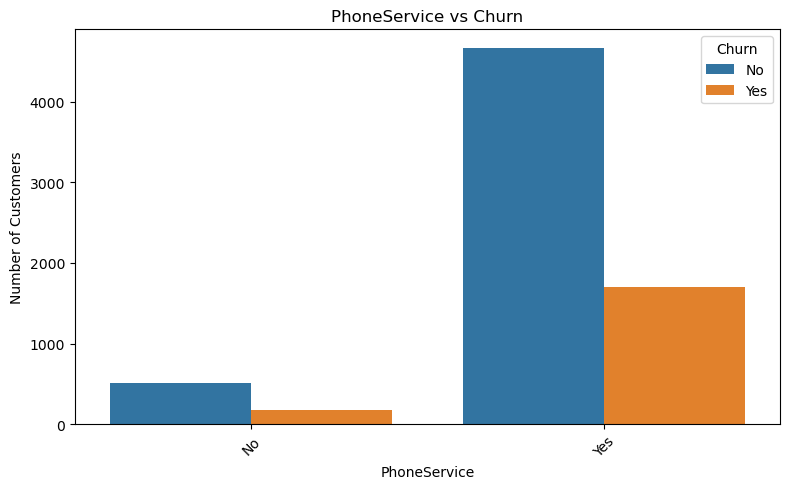


### PhoneService vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **Yes**, with a churn rate of **26.71%**.
- The category with the **lowest churn rate** is **No**, with a churn rate of **24.93%**.
- The difference in churn rates across categories suggests that `PhoneService` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


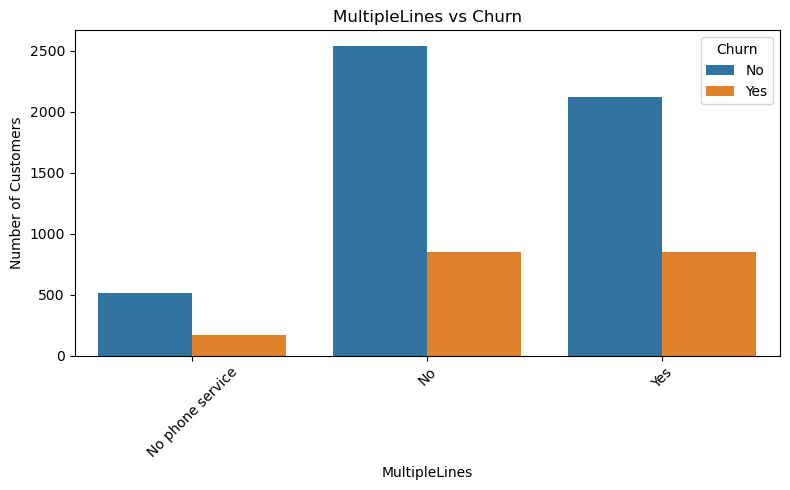


### MultipleLines vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **Yes**, with a churn rate of **28.61%**.
- The category with the **lowest churn rate** is **No phone service**, with a churn rate of **24.93%**.
- The difference in churn rates across categories suggests that `MultipleLines` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


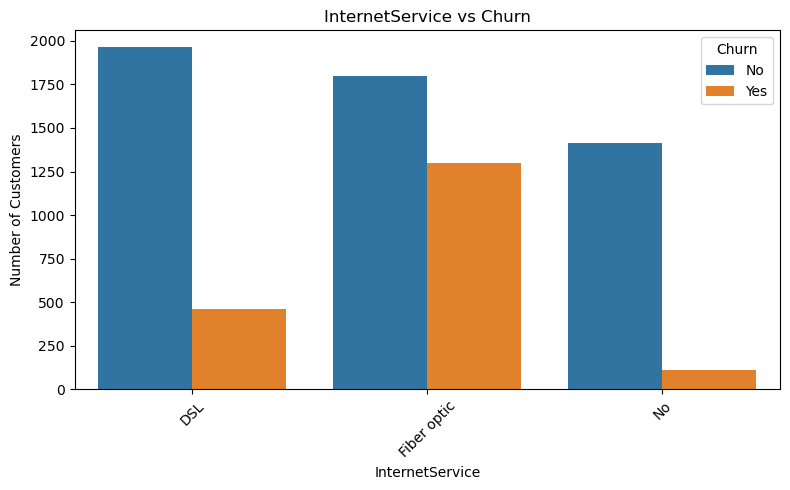


### InternetService vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **Fiber optic**, with a churn rate of **41.89%**.
- The category with the **lowest churn rate** is **No**, with a churn rate of **7.40%**.
- The difference in churn rates across categories suggests that `InternetService` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


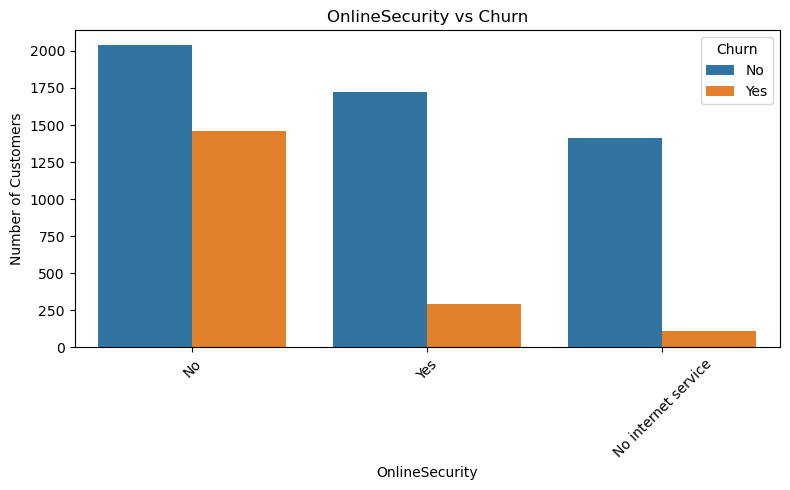


### OnlineSecurity vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **No**, with a churn rate of **41.77%**.
- The category with the **lowest churn rate** is **No internet service**, with a churn rate of **7.40%**.
- The difference in churn rates across categories suggests that `OnlineSecurity` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


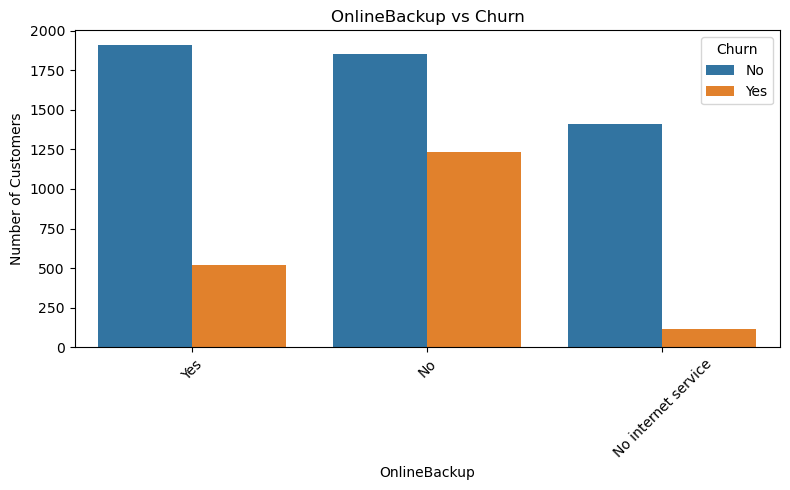


### OnlineBackup vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **No**, with a churn rate of **39.93%**.
- The category with the **lowest churn rate** is **No internet service**, with a churn rate of **7.40%**.
- The difference in churn rates across categories suggests that `OnlineBackup` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


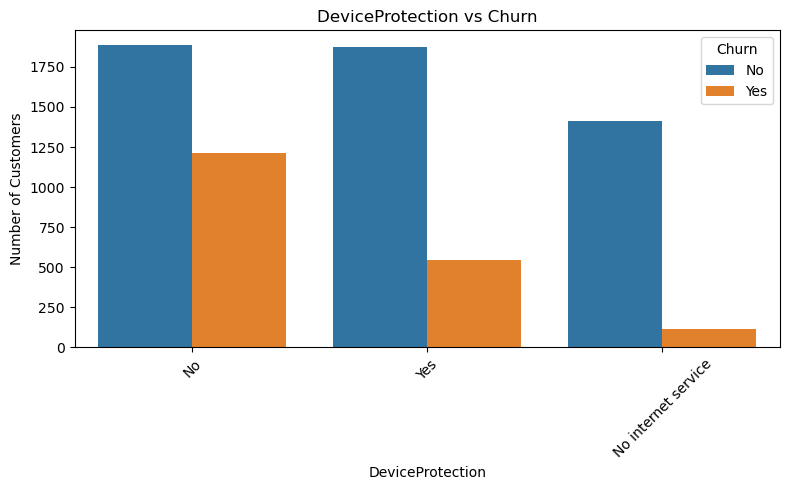


### DeviceProtection vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **No**, with a churn rate of **39.13%**.
- The category with the **lowest churn rate** is **No internet service**, with a churn rate of **7.40%**.
- The difference in churn rates across categories suggests that `DeviceProtection` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


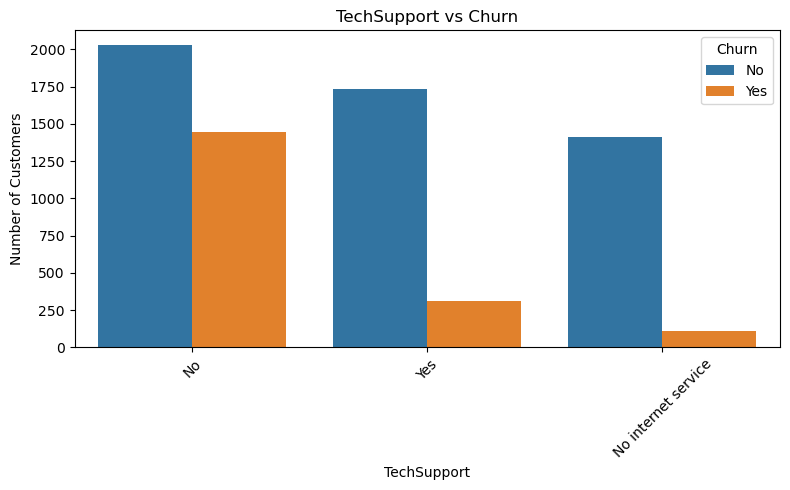


### TechSupport vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **No**, with a churn rate of **41.64%**.
- The category with the **lowest churn rate** is **No internet service**, with a churn rate of **7.40%**.
- The difference in churn rates across categories suggests that `TechSupport` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


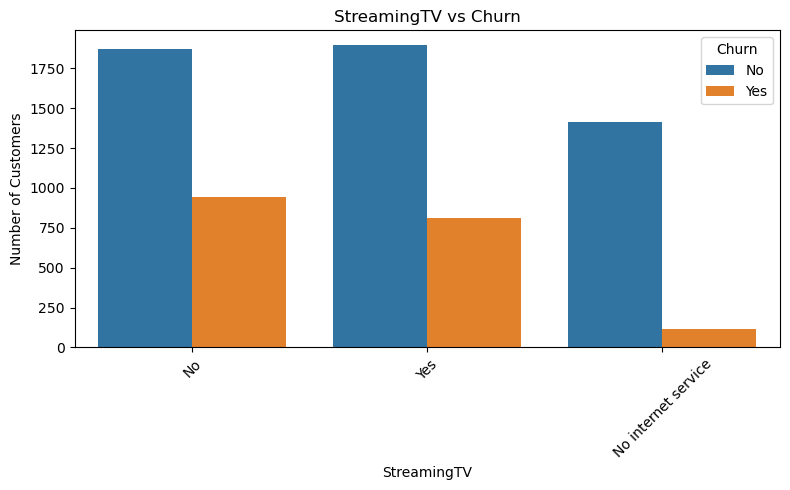


### StreamingTV vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **No**, with a churn rate of **33.52%**.
- The category with the **lowest churn rate** is **No internet service**, with a churn rate of **7.40%**.
- The difference in churn rates across categories suggests that `StreamingTV` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


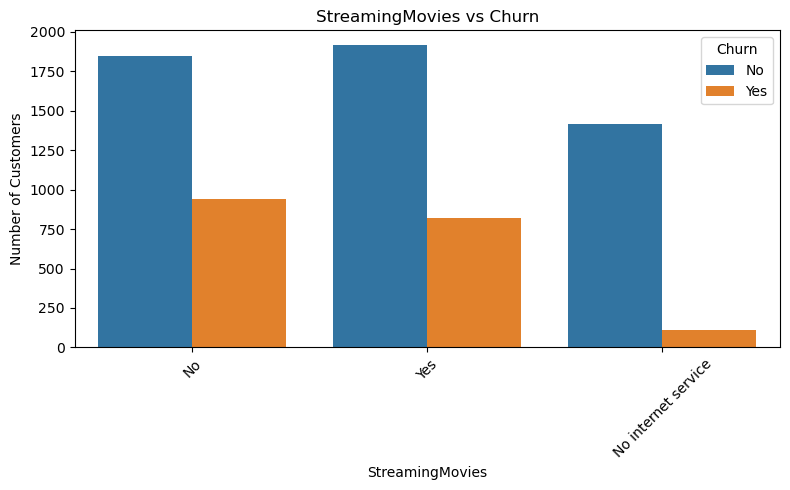


### StreamingMovies vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **No**, with a churn rate of **33.68%**.
- The category with the **lowest churn rate** is **No internet service**, with a churn rate of **7.40%**.
- The difference in churn rates across categories suggests that `StreamingMovies` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


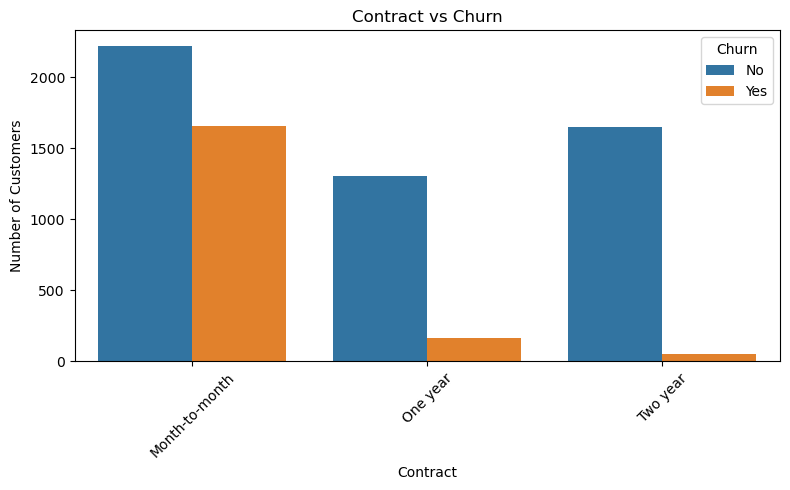


### Contract vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **Month-to-month**, with a churn rate of **42.71%**.
- The category with the **lowest churn rate** is **Two year**, with a churn rate of **2.83%**.
- The difference in churn rates across categories suggests that `Contract` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


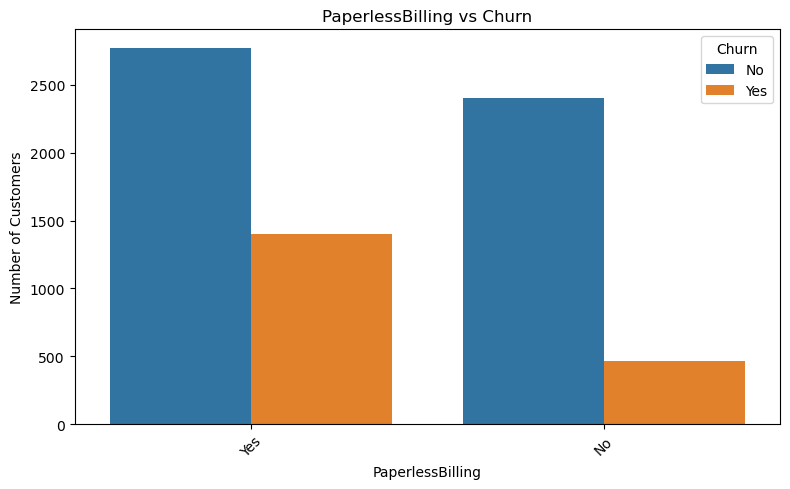


### PaperlessBilling vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **Yes**, with a churn rate of **33.57%**.
- The category with the **lowest churn rate** is **No**, with a churn rate of **16.33%**.
- The difference in churn rates across categories suggests that `PaperlessBilling` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


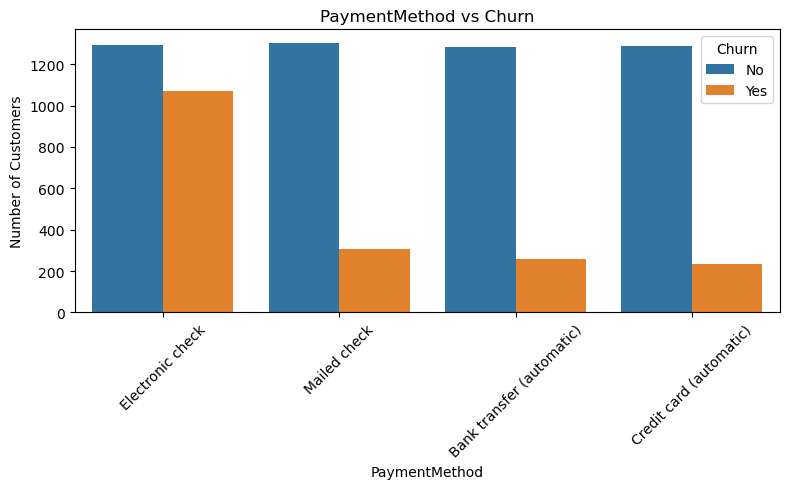


### PaymentMethod vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **Electronic check**, with a churn rate of **45.29%**.
- The category with the **lowest churn rate** is **Credit card (automatic)**, with a churn rate of **15.24%**.
- The difference in churn rates across categories suggests that `PaymentMethod` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


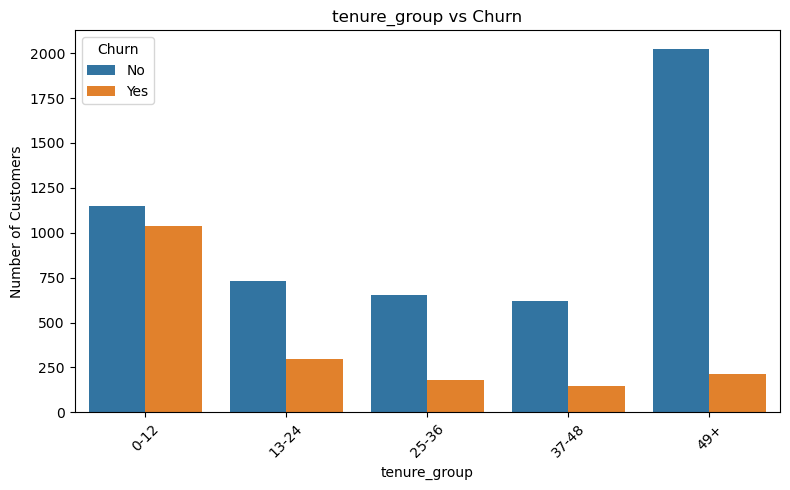

C:\Users\pmc-dinuka.SMTSL\AppData\Local\Temp\ipykernel_13724\212751835.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(i)["Churn"]



### tenure_group vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **0-12**, with a churn rate of **47.44%**.
- The category with the **lowest churn rate** is **49+**, with a churn rate of **9.51%**.
- The difference in churn rates across categories suggests that `tenure_group` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Remove Churn from the predictor categorical columns
cat_features = cat_cols.drop("Churn")

for i in cat_features:

    # Create count plot
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=i, hue="Churn")
    plt.title(f"{i} vs Churn")
    plt.xlabel(i)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Calculate churn rates for each category
    churn_rates = (
        df.groupby(i)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    highest_category = churn_rates.index[0]
    highest_rate = churn_rates.iloc[0]

    lowest_category = churn_rates.index[-1]
    lowest_rate = churn_rates.iloc[-1]

    # Display Markdown conclusion
    display(Markdown(f"""
### {i} vs Churn

**Conclusion:**

- The category with the **highest churn rate** is **{highest_category}**, with a churn rate of **{highest_rate:.2f}%**.
- The category with the **lowest churn rate** is **{lowest_category}**, with a churn rate of **{lowest_rate:.2f}%**.
- The difference in churn rates across categories suggests that `{i}` may have an association with customer churn.
- Further statistical analysis and model-based feature evaluation can be used to determine the importance of this variable in predicting churn.
"""))

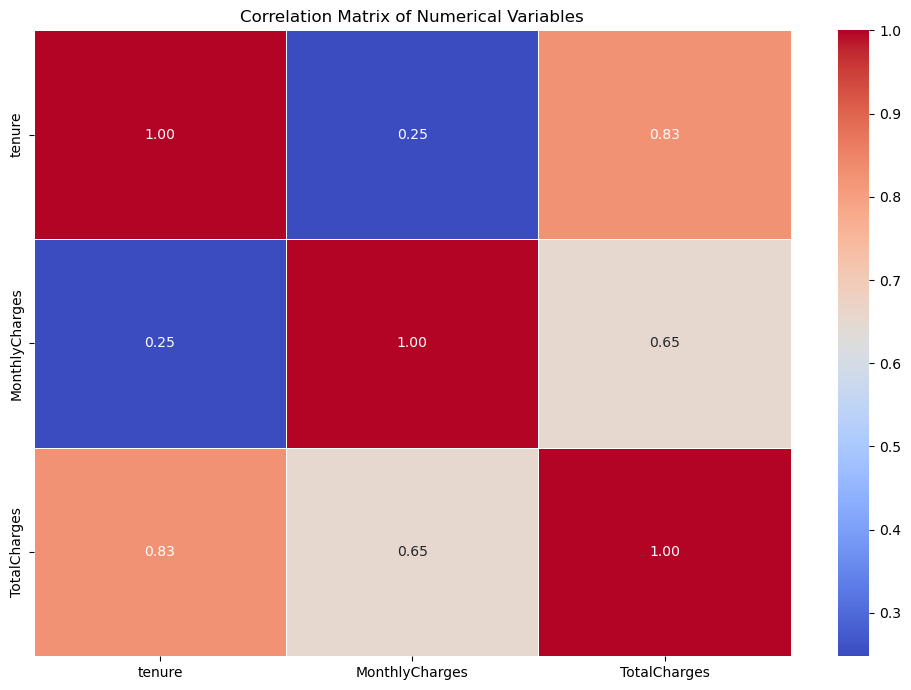


### Correlation Analysis – Conclusion

The correlation heatmap was used to examine the linear relationships among the numerical variables in the dataset. Correlation coefficients range from **-1 to +1**, where values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak or negligible linear relationship.

The strongest correlation identified among the numerical variables was between **`tenure`** and **`TotalCharges`**, with a correlation coefficient of **0.83**.

Overall, the heatmap helps identify potentially related features and provides an initial indication of possible multicollinearity. However, correlation measures only linear association and does not imply causation. Further analysis is required to determine the importance of these variables for predicting customer churn.


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Calculate correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()
plt.close()

# Find strongest correlations excluding self-correlations
corr_pairs = corr.where(
    ~__import__("numpy").eye(corr.shape[0], dtype=bool)
).stack()

# Strongest positive and negative correlations
strongest_pair = corr_pairs.abs().idxmax()
strongest_value = corr_pairs.loc[strongest_pair]

# Display Markdown conclusion
display(Markdown(f"""
### Correlation Analysis – Conclusion

The correlation heatmap was used to examine the linear relationships among the numerical variables in the dataset. Correlation coefficients range from **-1 to +1**, where values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak or negligible linear relationship.

The strongest correlation identified among the numerical variables was between **`{strongest_pair[0]}`** and **`{strongest_pair[1]}`**, with a correlation coefficient of **{strongest_value:.2f}**.

Overall, the heatmap helps identify potentially related features and provides an initial indication of possible multicollinearity. However, correlation measures only linear association and does not imply causation. Further analysis is required to determine the importance of these variables for predicting customer churn.
"""))

## Key Findings and Insights

The exploratory data analysis identified several important patterns and characteristics within the Telco Customer Churn dataset.

### Key Findings

1. **Customer Tenure**
   - Customer tenure ranges from 0 to 72 months.
   - Customers with shorter tenure show different churn behavior compared with customers who have remained with the company for longer periods.
   - Tenure appears to be an important variable for further investigation in churn prediction.

2. **Monthly Charges**
   - Monthly charges vary considerably across customers.
   - Differences in monthly charges were observed between customers who churned and those who remained.
   - This suggests that monthly charges may provide useful information for predicting churn.

3. **Contract Type**
   - Churn rates differ substantially across contract types.
   - Month-to-month customers show higher churn compared with customers on longer-term contracts.
   - Contract type therefore appears to be an important categorical feature.

4. **Internet Service**
   - Different internet-service categories exhibit different churn patterns.
   - This indicates that service type may be associated with customer attrition.

5. **Payment Method**
   - Churn rates vary across payment methods.
   - Certain payment categories show noticeably higher churn rates than others.

6. **Target Variable**
   - The `Churn` variable is not evenly distributed between customers who churned and those who remained.
   - This class imbalance should be considered when developing and evaluating classification models.

### Overall Insight

The EDA suggests that customer tenure, charges, contract characteristics, internet service, and payment methods may be important factors associated with customer churn. These variables should be considered during feature selection and machine learning model development.

## 14. EDA Conclusions

The Exploratory Data Analysis provided a comprehensive understanding of the Telco Customer Churn dataset, including its structure, data quality, variable distributions, and relationships between customer characteristics and churn.

The initial data-quality assessment found no duplicate records and no missing values in the original dataset. Data preprocessing was subsequently performed to ensure appropriate data types, transform categorical representations, create meaningful tenure groups, and remove the unique `customerID` identifier.

Univariate analysis showed that the numerical and categorical variables have different distributions and levels of representation across the customer population. Bivariate analysis identified differences in churn behavior across several numerical and categorical features. In particular, customer tenure, monthly charges, contract type, internet service, and payment method demonstrated potentially meaningful associations with churn.

Correlation analysis provided additional insight into relationships among numerical variables and helped identify potential multicollinearity considerations.

Overall, the EDA indicates that customer churn is influenced by multiple customer and service characteristics rather than a single variable. The identified patterns provide a strong foundation for the next stage of the project, which involves feature engineering, model development, and evaluation.

It should be noted that the relationships identified during EDA represent associations rather than causal relationships. Further statistical analysis and machine learning techniques are required to determine the predictive value of the identified features.

## 15. Recommendations and Next Steps

Based on the findings from the exploratory data analysis, the following steps are recommended for the machine learning stage:

1. **Feature Encoding**
   - Encode categorical variables using appropriate techniques such as one-hot encoding.
   - Ensure that the target variable `Churn` is appropriately encoded for classification.

2. **Feature Engineering**
   - Evaluate the usefulness of the newly created `tenure_group` feature.
   - Consider creating additional meaningful features based on customer services and billing characteristics.

3. **Feature Selection**
   - Investigate the predictive contribution of variables identified during EDA.
   - Examine potential multicollinearity among numerical features.

4. **Class Imbalance**
   - Evaluate the imbalance in the `Churn` target variable.
   - Consider appropriate techniques such as class weighting or resampling if required.

5. **Data Splitting**
   - Divide the dataset into training and testing sets before model development.
   - Apply preprocessing techniques appropriately to avoid data leakage.

6. **Model Development**
   - Establish a baseline classification model such as Logistic Regression.
   - Compare it with tree-based models such as Decision Tree, Random Forest, and other suitable classifiers.

7. **Model Evaluation**
   - Evaluate models using accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix.
   - Give particular attention to recall and F1-score if identifying customers at risk of churn is a priority.

8. **Model Tuning**
   - Apply cross-validation and hyperparameter tuning to improve model performance.
   - Compare the tuned models and select the most appropriate model based on the project's objectives.

9. **Business Interpretation**
   - Identify the characteristics associated with customers who are most likely to churn.
   - Translate model findings into potential customer-retention strategies.


## References

(1) - [Introduction](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
